In [45]:
import pandas as pd

df = pd.read_csv("./data/Autos/autos.csv.bz2", encoding="ISO-8859-1")

df = df[df["offerType"] == "Angebot"]
df = df[df["vehicleType"] == "kleinwagen"]
df = df[df["notRepairedDamage"] == "nein"]

df.dropna(inplace=True)

df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
17,2016-03-20 10:25:19,Renault_Twingo_1.2_16V_Aut.,privat,Angebot,1750,control,kleinwagen,2004,automatik,75,twingo,150000,2,benzin,renault,nein,2016-03-20 00:00:00,0,65599,2016-04-06 13:16:07
23,2016-03-12 19:43:07,Stadtflitzer,privat,Angebot,450,test,kleinwagen,1997,manuell,50,arosa,150000,5,benzin,seat,nein,2016-03-12 00:00:00,0,9526,2016-03-21 01:46:11
29,2016-03-08 19:55:19,Fiat_Punto_1.2,privat,Angebot,690,test,kleinwagen,2003,manuell,60,punto,150000,3,benzin,fiat,nein,2016-03-08 00:00:00,0,86199,2016-03-09 11:45:28


In [46]:
df["brand"].unique()

array(['volkswagen', 'skoda', 'renault', 'seat', 'fiat', 'ford', 'nissan',
       'audi', 'mercedes_benz', 'honda', 'peugeot', 'opel', 'smart',
       'kia', 'daihatsu', 'citroen', 'hyundai', 'mini', 'mitsubishi',
       'suzuki', 'bmw', 'lancia', 'daewoo', 'toyota', 'mazda',
       'chevrolet', 'dacia', 'alfa_romeo', 'subaru', 'trabant', 'rover',
       'chrysler', 'lada', 'volvo'], dtype=object)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51521 entries, 3 to 371516
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          51521 non-null  object
 1   name                 51521 non-null  object
 2   seller               51521 non-null  object
 3   offerType            51521 non-null  object
 4   price                51521 non-null  int64 
 5   abtest               51521 non-null  object
 6   vehicleType          51521 non-null  object
 7   yearOfRegistration   51521 non-null  int64 
 8   gearbox              51521 non-null  object
 9   powerPS              51521 non-null  int64 
 10  model                51521 non-null  object
 11  kilometer            51521 non-null  int64 
 12  monthOfRegistration  51521 non-null  int64 
 13  fuelType             51521 non-null  object
 14  brand                51521 non-null  object
 15  notRepairedDamage    51521 non-null  object
 16  dateCrea

### Aufgabe

Es soll ein Modell trainiert werden, welches auf Basis des Kilometerstandes und/oder des Baujahres den Preis vorhersagt

<Axes: xlabel='kilometer', ylabel='Count'>

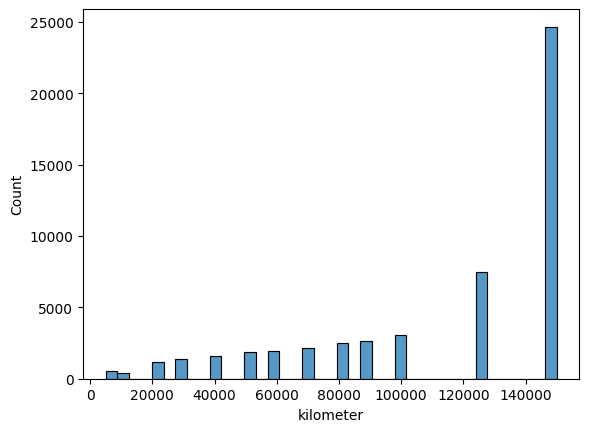

In [48]:
import seaborn as sns

sns.histplot(df["kilometer"], kde=False)

<Axes: xlabel='yearOfRegistration', ylabel='Count'>

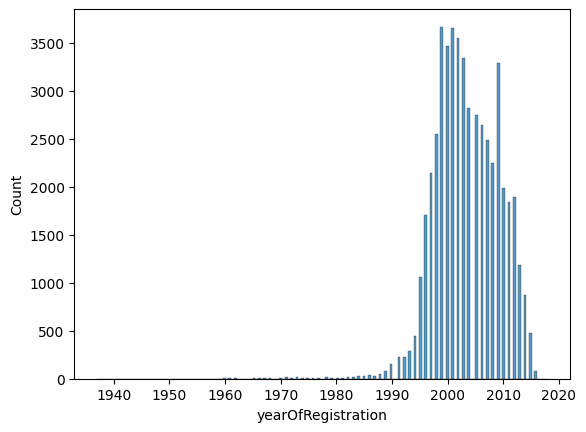

In [49]:
sns.histplot(df["yearOfRegistration"], kde=False)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["yearOfRegistration", "kilometer"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.5223139478949052
0.5507987945857247


In [51]:
import numpy as np
 
X_pred = np.array([[2000, 150000], [1998, 100000]])
model.predict(X_pred)

/home/sven/anaconda3/envs/ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1330.33633167, 2280.66105437])

### One-Hot Encoding (eine Spalte)

In [52]:
df["gearbox"]

3           manuell
4           manuell
17        automatik
23          manuell
29          manuell
            ...    
371472      manuell
371478      manuell
371499      manuell
371503      manuell
371516      manuell
Name: gearbox, Length: 51521, dtype: object

In [53]:
df["gearbox"].unique()

array(['manuell', 'automatik'], dtype=object)

In [54]:
df["gearbox_automatic"] = df["gearbox"] == "automatik"

In [55]:
df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,...,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,gearbox_automatic
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,...,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17,False
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,...,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21,False
17,2016-03-20 10:25:19,Renault_Twingo_1.2_16V_Aut.,privat,Angebot,1750,control,kleinwagen,2004,automatik,75,...,150000,2,benzin,renault,nein,2016-03-20 00:00:00,0,65599,2016-04-06 13:16:07,True
23,2016-03-12 19:43:07,Stadtflitzer,privat,Angebot,450,test,kleinwagen,1997,manuell,50,...,150000,5,benzin,seat,nein,2016-03-12 00:00:00,0,9526,2016-03-21 01:46:11,False
29,2016-03-08 19:55:19,Fiat_Punto_1.2,privat,Angebot,690,test,kleinwagen,2003,manuell,60,...,150000,3,benzin,fiat,nein,2016-03-08 00:00:00,0,86199,2016-03-09 11:45:28,False


In [56]:
X = df[["yearOfRegistration", "kilometer", "gearbox_automatic"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.5209254517249442
0.552809308371552


In [57]:
df["diesel"] = df["fuelType"] == "diesel"

In [58]:
X = df[["yearOfRegistration", "kilometer", "diesel"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.5727968096601599
0.5530268311501


### One-Hot Encoding (Mehrere Spalten)

In [59]:
from sklearn.preprocessing import OneHotEncoder

X = np.array(df[["brand"]])
oh = OneHotEncoder()
oh.fit(X)

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [60]:
print(oh.categories_)

[array(['alfa_romeo', 'audi', 'bmw', 'chevrolet', 'chrysler', 'citroen',
       'dacia', 'daewoo', 'daihatsu', 'fiat', 'ford', 'honda', 'hyundai',
       'kia', 'lada', 'lancia', 'mazda', 'mercedes_benz', 'mini',
       'mitsubishi', 'nissan', 'opel', 'peugeot', 'renault', 'rover',
       'seat', 'skoda', 'smart', 'subaru', 'suzuki', 'toyota', 'trabant',
       'volkswagen', 'volvo'], dtype=object)]


In [62]:
print(oh.transform(X).toarray())

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [64]:
X = df[["yearOfRegistration", "kilometer", "brand"]]
X.head()

,yearOfRegistration,kilometer,brand
3,2001,150000,volkswagen
4,2008,90000,skoda
17,2004,150000,renault
23,1997,150000,seat
29,2003,150000,fiat


In [68]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    [("brand_ct", OneHotEncoder(), ["brand"])],
    remainder="passthrough"
)

ct.fit(X)
X_transformed = ct.transform(X)

X_transformed.toarray()

array([[     0.,      0.,      0., ...,      0.,   2001., 150000.],
       [     0.,      0.,      0., ...,      0.,   2008.,  90000.],
       [     0.,      0.,      0., ...,      0.,   2004., 150000.],
       ...,
       [     0.,      0.,      0., ...,      0.,   1998., 150000.],
       [     0.,      0.,      0., ...,      0.,   1999.,  70000.],
       [     0.,      0.,      0., ...,      0.,   1998., 150000.]],
      shape=(51521, 36))

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.6352276263048365
0.6501643969667417
